# 📚 Module 10: Linear Regression — সম্পূর্ণ বাংলা গাইড

🔵 PART 01: Regression কী? Best Fit Line

##### 📌 Regression কেন দরকার?
Regression হলো Machine Learning-এর একটি পদ্ধতি যা continuous numeric value predict করে।
বাস্তব জীবনে:

🏠 বাড়ির দাম predict করা
🌡️ আগামীকালের তাপমাত্রা
📚 পড়ার সময় দেখে পরীক্ষার নম্বর

##### 📌 Best Fit Line কী?
Best Fit Line হলো একটি সরলরেখা যা সব data points-এর মাঝ দিয়ে যায় এবং সব points-এর সাথে দূরত্ব সবচেয়ে কম রাখে।
#### রেখার সমীকরণ:
y = mx + c

In [2]:
# প্রয়োজনীয় লাইব্রেরি import
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
# 💻 কোড ২: Dataset তৈরি

hours = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
marks = np.array([55, 60, 70, 80, 88])
hours, marks

(array([[ 2],
        [ 4],
        [ 6],
        [ 8],
        [10]]),
 array([55, 60, 70, 80, 88]))

ভাল প্রশ্ন—`reshape()` বিষয়টা প্রথমে একটু confusing লাগে, কিন্তু একবার ধরতে পারলে খুবই simple।

---

## 🔹 মূল ধারণা

তোমার এই লাইনটা দেখো:

```python
hours = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
```

এখানে `.reshape(-1, 1)` **array-এর shape (গঠন) পরিবর্তন করছে**।

---

## 🔹 Step-by-step বুঝি

### 1️⃣ reshape ছাড়া কী হয়?

```python
np.array([2, 4, 6, 8, 10])
```

👉 Output:

```python
[2 4 6 8 10]
```

👉 Shape:

```python
(5,)   # 1D array (একটা লাইন)
```

---

### 2️⃣ reshape(-1, 1) দিলে কী হয়?

```python
np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
```

👉 Output:

```python
[[ 2]
 [ 4]
 [ 6]
 [ 8]
 [10]]
```

👉 Shape:

```python
(5, 1)   # 2D array (5 rows, 1 column)
```

---

## 🔹 এখন প্রশ্ন: `-1` কেন?

👉 `-1` মানে:

> "তুমি (NumPy) নিজে হিসাব করে নাও কত rows লাগবে"

আমরা বলছি:

```python
.reshape(-1, 1)
```

মানে:

* column = 1 (fixed)
* row = auto

👉 NumPy দেখে:

* মোট 5টা element আছে
* column = 1
  👉 তাই row = 5

---

## 🔹 Visual comparison

| Without reshape | With reshape(-1,1)       |
| --------------- | ------------------------ |
| `[2,4,6,8,10]`  | `[[2],[4],[6],[8],[10]]` |
| Shape: (5,)     | Shape: (5,1)             |

---

## 🔹 sklearn কেন এটা চায়?

`sklearn` model (যেমন `LinearRegression`) expects:

```python
X → 2D (n_samples, n_features)
y → 1D
```

👉 তোমার ক্ষেত্রে:

* `hours` = input (X)
* `marks` = output (y)

👉 তাই:

```python
hours.shape → (5,1) ✅
marks.shape → (5,) ✅
```

---

## 🔹 সহজভাবে মনে রাখো

👉 `reshape(-1,1)` মানে:

> "list কে column বানাও"

---

## 🔹 Bonus: উল্টো করলে কী হবে?

```python
.reshape(1, -1)
```

👉 Output:

```python
[[2 4 6 8 10]]
```

👉 Shape:

```
(1,5)  # 1 row, 5 columns
```

---

## 🎯 এক লাইনের summary

👉 `reshape(-1,1)` = 1D list → column format (ML model-এর জন্য প্রয়োজন)

---

তুমি চাইলে আমি এটা **diagram বা animation style example** দিয়ে আরও clear করে দেখাতে পারি 👍


In [4]:
# কোড ৩: Model Train করা

model = LinearRegression()
model.fit(hours, marks)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
# 💻 কোড ৪: m এবং c দেখা

print("m: ", model.coef_[0])
print("c: ", model.intercept_)

m:  4.3
c:  44.8


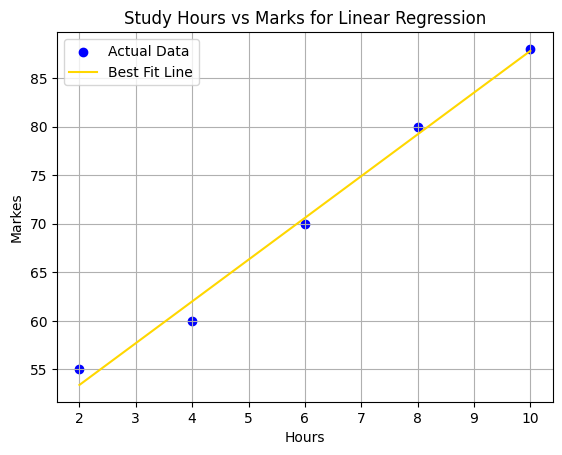

In [6]:
# 💻 কোড ৫: Best Fit Line আঁকা

plt.scatter(hours, marks, color='blue', label="Actual Data")

predicted_markes = model.predict(hours)
plt.plot(hours, predicted_markes, color = 'gold', label="Best Fit Line")

plt.xlabel("Hours")
plt.ylabel("Markes")
plt.title("Study Hours vs Marks for Linear Regression")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
#💻 কোড ৬: নতুন Student-এর Prediction

new_hours = np.array([[7]])
prediction = model.predict(new_hours)
print("Predicted Marks: ", prediction[0])

Predicted Marks:  74.89999999999999


## 🔵 PART 02: Cost Function এবং Gradient Descent
#### 📌 মূল প্রশ্ন
#### Model কীভাবে নিজে নিজে সেরা m এবং c বের করে?
উত্তর: Cost Function + Gradient Descent

### 📌 Prediction Error কী?
Error = Actual - Predicted

### 📌 Mean Squared Error (MSE) — Cost Function
#### সমাধান: Error-কে Square করো → সব positive হয়, বড় error বেশি penalty পায়।
##### MSE = (1/n) × Σ(actual - predicted)²

##### 📌 Gradient Descent — পাহাড় থেকে নামা
উপমা: অন্ধকারে পাহাড়ের চূড়ায় দাঁড়িয়ে আছো। নিচে নামতে হবে।

দেখতে পাচ্ছো না, কিন্তু পায়ে অনুভব করতে পারছো কোন দিকে ঢাল আছে
ঢালের দিকে ছোট ছোট পদক্ষেপ নাও
বারবার করতে থাকো যতক্ষণ সমতলে না পৌঁছাও

এটাই Gradient Descent!

#### Cost function-এর "পাহাড়" আছে
#### Gradient Descent সেই পাহাড়ের সর্বনিম্ন বিন্দু খোঁজে
#### সেই বিন্দুতেই সেরা m এবং c

In [8]:
# 💻 কোড ৭: Libraries Import

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error

In [9]:
# 💻 কোড ৮: Dataset (আগের মতোই)

hours = np.array(([2, 4, 6, 8, 10])).reshape(-1, 1)
marks = np.array([55, 60, 70, 80, 88])

print(hours, marks)

[[ 2]
 [ 4]
 [ 6]
 [ 8]
 [10]] [55 60 70 80 88]


In [10]:
# 💻 কোড ৯: LinearRegression দিয়ে Fit
# Closed-Form (direct mathematical solution)
lin_reg = LinearRegression()
lin_reg.fit(hours, marks)

print("m: ", lin_reg.coef_[0])
print("c: ", lin_reg.intercept_)

m:  4.3
c:  44.8


ব্যাখ্যা:

LinearRegression → সরাসরি mathematical formula দিয়ে সেরা m এবং c বের করে
এটাকে বলে Closed-Form Solution বা Normal Equation
ছোট dataset-এর জন্য দ্রুত ও নির্ভুল

In [11]:
# 💻 কোড ১০: MSE Calculate করা

pred_marks = lin_reg.predict(hours)
mse_lin = mean_squared_error(marks, pred_marks)
print("MSE for LinearRegression:", mse_lin)

MSE for LinearRegression: 1.5200000000000033


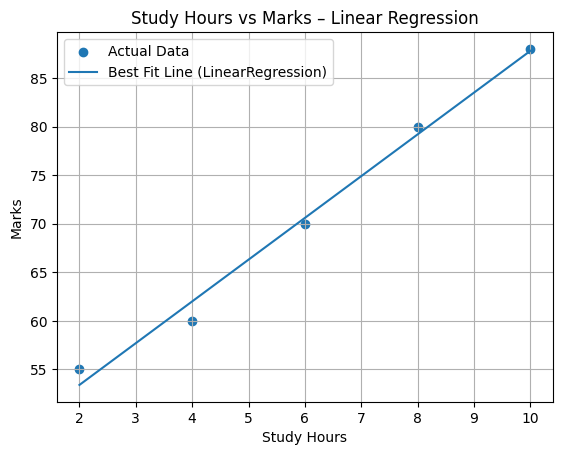

In [12]:
#💻 কোড ১১: Graph আঁকা
# Data এবং Best Fit Line visualize
plt.scatter(hours, marks, label="Actual Data")
plt.plot(hours, pred_marks, label="Best Fit Line (LinearRegression)")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks – Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# 💻 কোড ১২: SGDRegressor দিয়ে Gradient Descent

# Gradient Descent-based model
sgd_reg = SGDRegressor(
    max_iter=1000,           # সর্বোচ্চ কতবার update করবে
    learning_rate="invscaling",  # learning rate ধীরে ধীরে কমে
    eta0=0.01,              # শুরুর learning rate
    random_state=42         # reproducibility
)

sgd_reg.fit(hours, marks)
print("m: ", sgd_reg.coef_[0])
print("c: ", sgd_reg.intercept_[0])

pred_sgd = sgd_reg.predict(hours)
mse_sgd = mean_squared_error(marks, pred_sgd)
print("MSE of SGDRegressor: ", mse_sgd)

m:  5.698065492806587
c:  34.475265427340794
MSE of SGDRegressor:  20.906115830567398


C:\Users\evan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


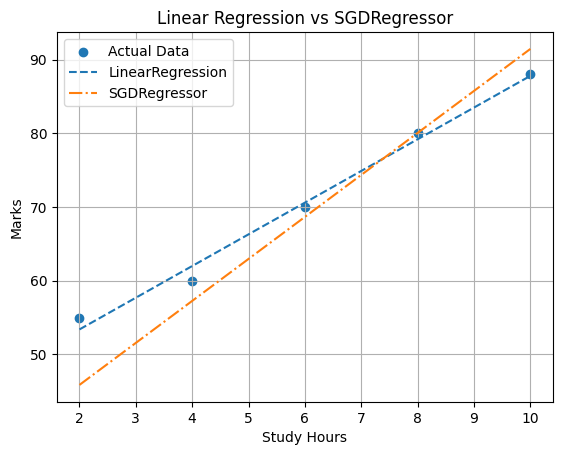

In [15]:
#💻 কোড ১৩: দুটো Line তুলনা

# দুটো model তুলনা
plt.scatter(hours, marks, label="Actual Data")

plt.plot(hours, pred_marks, label="LinearRegression", linestyle="--")
plt.plot(hours, pred_sgd, label="SGDRegressor", linestyle="-.")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear Regression vs SGDRegressor")
plt.legend()
plt.grid(True)
plt.show()


## 🔵 PART 03: Regression Evaluation Metrics

---

## 📌 কেন Metrics দরকার?
Model বানানোর পর সবচেয়ে গুরুত্বপূর্ণ প্রশ্ন:
👉 **“Modelটা আসলে কতটা ভালো?”**

এই প্রশ্নের উত্তর দেয় **Evaluation Metrics** —
এগুলো হলো model-এর **report card**।

🎯 Regression-এর জন্য ৩টি সবচেয়ে গুরুত্বপূর্ণ metric:
- **MAE (Mean Absolute Error)** → গড় ভুল কত
- **RMSE (Root Mean Squared Error)** → বড় ভুলকে বেশি শাস্তি দেয়
- **R² (R-squared)** → model কতটুকু explain করতে পারে

---

## 📌 1. MAE — Mean Absolute Error

### 🔢 Formula
```

MAE = (1/n) × Σ|actual - predicted|

```

### 🧮 Example
```

|65-68| = 3
|75-73| = 2
|82-78| = 4
|88-83| = 5
|95-88| = 7

```
```

MAE = (3+2+4+5+7) ÷ 5 = 4.2

```

### 🎯 Interpretation
👉 Model গড়ে **৪.২ ইউনিট ভুল করছে**

### ✅ Pros
- সহজে বোঝা যায়
- outlier দ্বারা খুব বেশি প্রভাবিত হয় না

### ⚠️ Cons
- বড় ভুলকে আলাদা করে গুরুত্ব দেয় না

---

## 📌 2. RMSE — Root Mean Squared Error

### 🔢 Formula
```

RMSE = √[(1/n) × Σ(actual - predicted)²]

```

### 🧮 Step-by-step
```

Squared Errors:
3²=9, 2²=4, 4²=16, 5²=25, 7²=49

```
```

Mean = (9+4+16+25+49) ÷ 5 = 20.6

```
```

RMSE = √20.6 ≈ 4.5

```

### 🎯 Interpretation
👉 বড় ভুলকে বেশি weight দিয়ে average error ≈ **৪.৫**

### ✅ Pros
- বড় ভুল (outlier) detect করতে খুব ভালো
- sensitive metric

### ⚠️ Cons
- outlier থাকলে value হঠাৎ বেড়ে যায়

---

## 📌 3. R² — Coefficient of Determination

### 🔢 Formula
```

R² = 1 - (SSres / SStot)

```

### 🎯 Interpretation
👉 Model data-এর **variation কতটা explain করতে পারছে**

| R² Value | Meaning |
|----------|--------|
| 1.0 | Perfect fit |
| 0.75 | ৭৫% explain করছে |
| 0.0 | কিছুই explain করতে পারছে না |
| < 0 | Model খুব খারাপ (baseline থেকেও খারাপ) |

👉 সহজভাবে:
> **R² = 0.8 → Model ৮০% বুঝেছে, ২০% এখনো unexplained**

### ⚠️ Important Note
- High R² মানেই model সবসময় ভালো না
- Overfitting হলেও R² বেশি হতে পারে

---

## 📊 MAE vs RMSE vs R² (Quick Comparison)

| Metric | কী মাপে | Special Behavior | Use Case |
|--------|--------|----------------|----------|
| MAE | Average error | সব ভুল equal | সহজ ব্যাখ্যার জন্য |
| RMSE | Weighted error | বড় ভুল বেশি penalty | high-risk prediction |
| R² | Explained variance | scale-free | overall performance |

---

## 📌 কোন Metric কখন ব্যবহার করবে?

- ✅ **MAE** → যখন explainability গুরুত্বপূর্ণ
- ✅ **RMSE** → যখন বড় ভুল একদম acceptable না
- ✅ **R²** → model-এর overall quality বুঝতে

---

## 💡 Pro Tips

- কখনো **একটা metric-এর উপর নির্ভর করো না**
- MAE + RMSE একসাথে দেখলে error distribution বোঝা যায়
- R² দিয়ে overall fit বুঝো, কিন্তু blind trust করো না
- Always check **residuals + plots** for deeper insight

---

## 🧠 Final Insight

👉 **MAE = “গড়ে কত ভুল”**
👉 **RMSE = “বড় ভুল হলে কত সমস্যা”**
👉 **R² = “model কতটা বুঝেছে”**

✔️ তিনটা একসাথে = complete picture
```


In [16]:
# 💻 কোড ১৪: Libraries Import
# Metrics-এর libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Model train
[53.4 62.  70.6 79.2 87.8]

# Metrics calculate

Results দেখা
MAE:  1.040000000000002
MSE: 1.5200000000000033
RMSE: 1.2328828005937966
R²: 0.9898286937901499
# Graph আঁকা


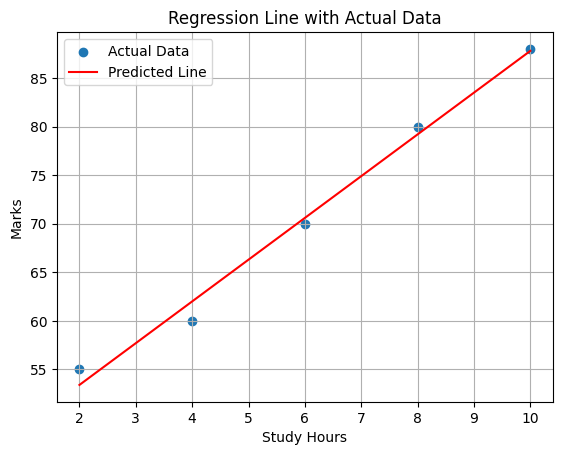

In [21]:
# Dataset
hours = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
marks = np.array([55, 60, 70, 80, 88])
hours, marks
print()
print("# Model train")

model = LinearRegression()
model.fit(hours, marks)
pred = model.predict(hours)
print(pred)
print()
print("# Metrics calculate")
mae  = mean_absolute_error(marks, pred)
mse  = mean_squared_error(marks, pred)
rmse = np.sqrt(mse)           # MSE-এর square root = RMSE
r2   = r2_score(marks, pred)
print()
print( "Results দেখা")
print("MAE: ", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)
print("# Graph আঁকা")

plt.scatter(hours, marks, label="Actual Data")
plt.plot(hours, pred, color="red", label="Predicted Line")

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Regression Line with Actual Data")
plt.legend()
plt.grid(True)
plt.show()


## 🔵 PART 04: Assumptions ও Limitations

---

## 📌 কেন Assumptions গুরুত্বপূর্ণ?

Linear Regression একটি powerful tool, কিন্তু কিছু শর্ত (assumptions) না মানলে:

- ❌ Predictions ভুল হবে
- ❌ Coefficients বিভ্রান্তিকর হবে
- ❌ Error বেড়ে যাবে

🏠 **উপমা:**
ভিত্তি দুর্বল হলে যেমন বাড়ি ভেঙে পড়ে, তেমনি assumptions না মানলে model ভেঙে যায়।

---

## 📌 ৫টি গুরুত্বপূর্ণ Assumptions

---

### ✅ 1. Linearity (রৈখিকতা)

👉 Input এবং Output-এর মধ্যে **linear relationship** থাকতে হবে।

- ✔️ ভালো: পড়ার সময় vs নম্বর
- ❌ খারাপ: বয়স vs আয় (curve relationship)

🔍 **কীভাবে চেক করবো?**
→ Scatter plot

---

### ✅ 2. Independence of Errors

👉 প্রতিটি error একে অপরের থেকে স্বাধীন হতে হবে।

- ✔️ ভালো: দৈনিক আইসক্রিম বিক্রি
- ❌ খারাপ: তাপমাত্রা prediction (time dependency থাকে)

⚠️ **Violation হলে:** pattern থেকে যায় → model ভুল শেখে

---

### ✅ 3. Homoscedasticity (সমবিভেদ)

👉 সব prediction-এর জন্য error-এর variance সমান হতে হবে।

📊 **Example: Salary vs Experience**

- Junior → tightly clustered
- Senior → wide spread

➡️ Funnel shape = ❌ **Heteroscedasticity**

---

### ✅ 4. Normality of Residuals

👉 Errors normal distribution (bell curve) অনুসরণ করবে।

- ✔️ symmetric distribution
- ❌ skewed errors

📌 কেন দরকার?
→ Statistical inference (confidence interval, hypothesis test)

---

### ✅ 5. No Multicollinearity

👉 Features একে অপরের সাথে খুব বেশি correlated হওয়া যাবে না।

📊 **Example:**
- Bedroom
- Bathroom
- Square footage

➡️ সবই related → model confuse হয়

⚠️ সমস্যা:
- Coefficient unstable হয়
- Feature importance বোঝা কঠিন

---

## 📌 Linear Regression-এর Limitations

| সমস্যা | সমাধান |
|------|--------|
| Non-linear pattern ধরতে পারে না | Polynomial Regression / Neural Network |
| Outlier sensitive | Robust Regression / Outlier removal |
| Classification করতে পারে না | Logistic Regression |
| Complex interaction ধরতে পারে না | Feature Engineering / Advanced models |

---

## 📌 কখন Linear Regression ব্যবহার করব না?

- ❌ Scatter plot-এ curve থাকলে
- ❌ Time-based pattern (seasonality) থাকলে
- ❌ অনেক outlier থাকলে
- ❌ Features highly correlated হলে
- ❌ Output যদি binary হয়

---

## 🔵 PART 05: Logistic Regression ও Sigmoid Function

---

## 📌 কেন Linear Regression Classification-এ কাজ করে না?

Linear Regression output দিতে পারে:

- -2, 1.7, 5.1 ... ❌

কিন্তু Classification-এ দরকার:

- ✔️ 0 বা 1
- ✔️ Probability (0 → 1)

⚠️ সমস্যা:
- Output uncontrolled
- No clear boundary
- Hard to interpret

---

## 📌 আমাদের দরকার Probability

👉 Real-world প্রশ্ন:

- “এই patient-এর disease হওয়ার সম্ভাবনা কত?”
- “এই email spam হওয়ার সম্ভাবনা কত?”

➡️ Output সবসময় **0 থেকে 1-এর মধ্যে** হতে হবে

---

## 📌 Sigmoid Function — মূল হাতিয়ার

### 🔢 Formula
```

σ(z) = 1 / (1 + e^(-z))

```

👉 এটি যেকোনো real number → **(0, 1)** range-এ নিয়ে আসে

---

### 📊 Behavior

| z মান | σ(z) | অর্থ |
|------|------|------|
| খুব ছোট (-∞) | ≈ 0 | Class 0 |
| 0 | 0.5 | Uncertain |
| খুব বড় (+∞) | ≈ 1 | Class 1 |

📈 Shape: **S-shaped curve**

---

## 📌 Logistic Regression কীভাবে কাজ করে?

### Step 1: Linear Score
```

z = m₁x₁ + m₂x₂ + ... + c

```

### Step 2: Sigmoid Apply
```

probability = σ(z)

```

### Step 3: Interpretation
👉 Example: probability = 0.785
→ **৭৮.৫% chance**

---

## 📌 বাস্তব উদাহরণ

- Student: ৮ ঘণ্টা পড়েছে
- Model: z = 1.3

```

σ(1.3) = 1 / (1 + e^(-1.3)) ≈ 0.785

```

👉 Result: **৭৮.৫% chance pass করবে**

---

## 📌 Decision Boundary

👉 Final class বের করতে threshold ব্যবহার করা হয়:

- probability ≥ 0.5 → Class 1
- probability < 0.5 → Class 0

📊 Example:
- 0.62 → Pass
- 0.45 → Fail

➡️ 2D-তে এটি একটি **straight line**

---

## 📌 Logistic Regression-এর Limitations

- শুধুমাত্র **linear boundary** আঁকতে পারে
- Complex pattern (যেমন XOR) handle করতে পারে না

➡️ Solution:
- Neural Network
- Kernel methods

---

## 📊 Linear vs Logistic Regression

| দিক | Linear Regression | Logistic Regression |
|-----|------------------|---------------------|
| Output | (-∞ → +∞) | (0 → 1) |
| কাজ | Continuous prediction | Classification |
| Boundary | নেই | Threshold (0.5) |
| Use case | House price | Spam detection |

---

## 🧠 Final Insight

👉 **Linear Regression** → “কত?”
👉 **Logistic Regression** → “হবে কি হবে না?”

✔️ Regression = Quantity
✔️ Classification = Probability + Decision
```
